In [100]:
import pandas as pd

In [101]:
data = pd.read_csv('data-export.csv')

In [102]:
data.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [103]:
data.columns = data.iloc[0]
data = data[1:]

In [104]:
data.head()

,Session primary channel group (Default channel group),Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
5,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [135]:
data['Date + hour (YYYYMMDDHH)'] = pd.to_datetime(data['Date + hour (YYYYMMDDHH)'], format="%Y%m%d%H")
data['Sessions'] = pd.to_numeric(data['Sessions'])

time_series_data = data.groupby('Date + hour (YYYYMMDDHH)').agg({'Sessions':'sum'}).sort_index()

In [111]:
time_series_data.head()

,Sessions
Date + hour (YYYYMMDDHH),
2024-04-06 00:00:00,270
2024-04-06 01:00:00,142
2024-04-06 02:00:00,142
2024-04-06 03:00:00,122
2024-04-06 04:00:00,102


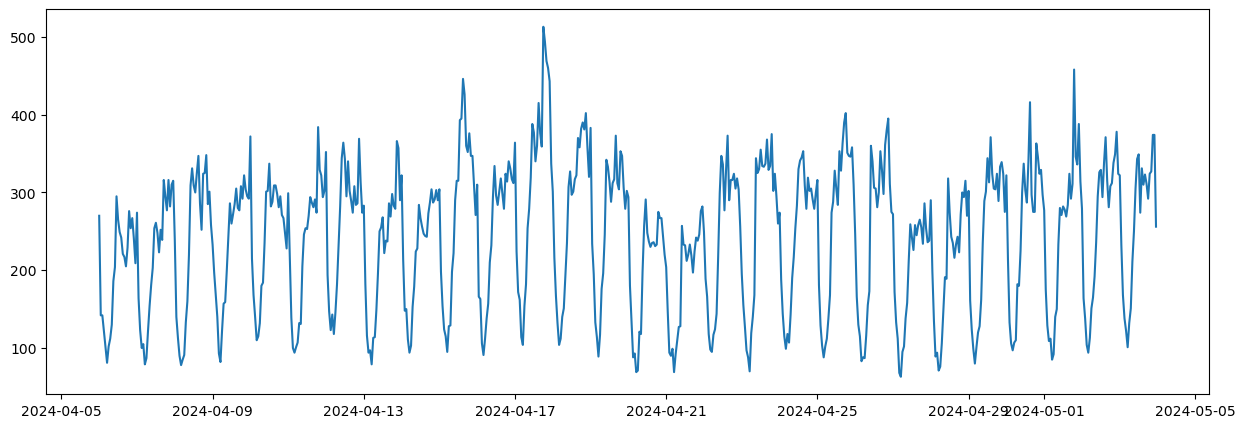

In [112]:
import matplotlib.pyplot as pllt

plt.figure(figsize=(15,5))

plt.plot(time_series_data.index, time_series_data.values)

plt.show()

# Stationarity - stat properties(mean, variance, etc.) rermain constant over time 

## Methods like the Augmented Dickey-Fuller (ADF) test, Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test, and visual inspection of time series plots. 

### Null Hypothesis (H₀): The series has a unit root (non-stationary)
### Alternative Hypothesis (H₁): The series is stationary

In [113]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(time_series_data)
print(f'ADF is: {result[0]}')
print(f'p-value is: {result[1]}')
print(f'usedlag is: {result[2]}')
print(f'nobs is: {result[3]}')
print(f'crit values are: {result[4]}')
print(f'icbest is: {result[5]}')
# print(f'resstore is: {result[6]}'

ADF is: -3.0123861134761603
p-value is: 0.033753772131504815
usedlag is: 20
nobs is: 651
crit values are: {'1%': -3.440434903803665, '5%': -2.865989920612213, '10%': -2.569139761751388}
icbest is: 6460.9207987176305


### Interpreting the Results
#### ADF Statistic: If it's significantly lower than the critical values, reject the null.
#### p-value: If p < 0.05, the series is likely stationary.
#### Critical Values: Used for comparing with the ADF statistic. 

# Seasonality - pertains to recurring patterns or fluctuations in a time series that occur at regular intervals. 

## Testing for seasonality in Python can be accomplished through decomposition analysis and autocorrelation function (ACF) plots.

##### Autocorrelation measures the relationship between a variable's current and past values at different time lags. On the other hand, partial autocorrelation quantifies the direct relationship between a variable's current value and its past values, excluding the influence of intermediate-lagged variables.



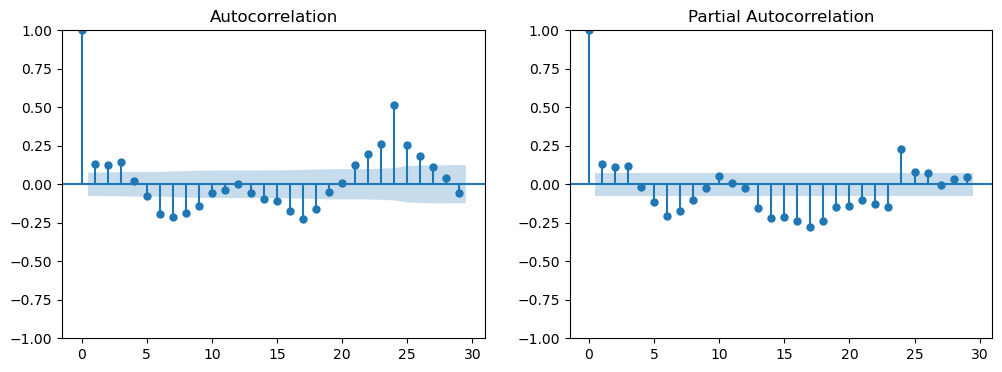

In [114]:
time_series_diff = time_series_data.diff().dropna()

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2, figsize=(12,4))

plot_acf(time_series_diff, ax = ax[0])
plot_pacf(time_series_diff, ax = ax[1])

plt.show()

### PACF (Partial Autocorrelation Function): This plot helps determine the p parameter for the AR part of the model. You look for the lag after which most partial autocorrelations are not significantly different from zero. In our plot, the PACF shows a significant spike at lag 1 and then cuts off, suggesting an AR part of order 1. Therefore, p=1.
### ACF (Autocorrelation Function): This plot helps identify the q parameter for the MA part of the model. You look for the lag after which most autocorrelations are not significantly different from zero. The ACF plot in our case tails off gradually, but considering the first significant spike is essential. Since the spike at lag 1 is significant and there’s a gradual tailing off rather than a sharp cut-off, it suggests a potential MA component. However, the tailing-off nature complicates the exact determination of q, but a starting point of q=1 could be considered.
### The other parameter is d, representing seasonality. In our case, as seasonality exists, we can choose the value of d as 1.



# Predicting future values based on historical data using SARIMA

In [140]:
time_series_data = time_series_data.asfreq('H')

In [145]:
time_series_data

,Sessions
Date + hour (YYYYMMDDHH),
2024-04-06 00:00:00,270
2024-04-06 01:00:00,142
2024-04-06 02:00:00,142
2024-04-06 03:00:00,122
2024-04-06 04:00:00,102
...,...
2024-05-03 19:00:00,324
2024-05-03 20:00:00,327
2024-05-03 21:00:00,374


In [195]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(time_series_data, order=(1, 1, 1), seasonal_order=(1, 1, 1, 24))

results = model.fit()

 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.74212D+00    |proj g|=  6.85385D-02

At iterate    5    f=  4.70443D+00    |proj g|=  1.38562D-02

At iterate   10    f=  4.62848D+00    |proj g|=  4.98725D-03

At iterate   15    f=  4.62397D+00    |proj g|=  2.06890D-02

At iterate   20    f=  4.62304D+00    |proj g|=  4.70006D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     23     32      1     0     0   2.767D-06   4.623D+00
  F =   4.6230161093171320     

CONVERG

In [196]:
forecast = results.forecast(steps=24)

In [197]:
forecast = forecast.reset_index()

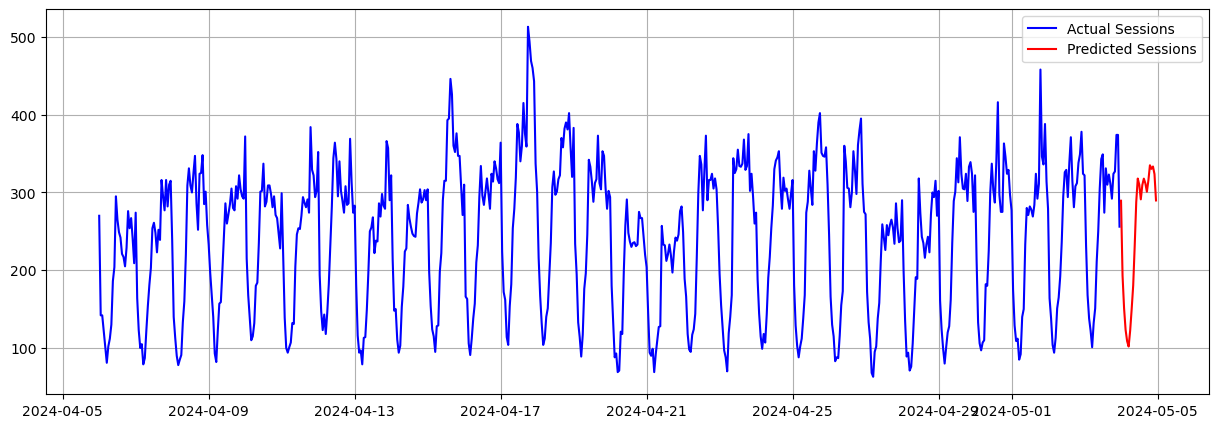

In [198]:
plt.figure(figsize=(15,5))
plt.plot(time_series_data.index, time_series_data.values, color='blue', label='Actual Sessions')
plt.plot(forecast['index'], forecast['predicted_mean'], color='red', label='Predicted Sessions')


plt.legend()
plt.grid(True)
plt.show()